In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import joblib

# Training File Path
file_path = r"D:\Data\Prediction_Data.xlsx"

# Sheet Name
sheet_name = 'vw_churndata'

# Read Excel File
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Clean Column Names
data.columns = data.columns.str.strip() \
                           .str.replace(" ", "_") \
                           .str.replace(r"[^\w]", "", regex=True)

# Show Data
print(data.head())

  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card           65.6        593.30          0.00   
1      Credit Card          

In [2]:
# Drop Unwanted Columns
data = data.drop(
    ['Customer_ID', 'Churn_Category', 'Churn_Reason'],
    axis=1,
    errors='ignore'
)

# Fill Missing Values
data = data.fillna('Unknown')

# Columns To Encode
columns_to_encode = [

    'Gender',
    'Married',
    'State',
    'Value_Deal',
    'Phone_Service',
    'Multiple_Lines',
    'Internet_Service',
    'Internet_Type',
    'Online_Security',
    'Online_Backup',
    'Device_Protection_Plan',
    'Premium_Support',
    'Streaming_TV',
    'Streaming_Movies',
    'Streaming_Music',
    'Unlimited_Data',
    'Contract',
    'Paperless_Billing',
    'Payment_Method'

]

# Encode Data
label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(
        data[column].astype(str)
    )

# Encode Target Column
data['Customer_Status'] = data['Customer_Status'].map({
    'Stayed': 0,
    'Churned': 1
})

print(data.head())

   Gender  Age  Married  State  Number_of_Referrals  Tenure_in_Months  \
0       1   35        0      4                    7                27   
1       0   45        1     12                   14                13   
2       1   51        0     21                    4                35   
3       1   79        0      9                    3                21   
4       0   80        0     17                    3                 8   

   Value_Deal  Phone_Service  Multiple_Lines  Internet_Service  ...  Contract  \
0           5              1               0                 1  ...         1   
1           5              1               2                 1  ...         0   
2           4              1               0                 1  ...         0   
3           3              1               0                 1  ...         0   
4           5              1               0                 1  ...         0   

   Paperless_Billing  Payment_Method  Monthly_Charge  Total_Charges  \
0  

In [3]:
# Features
X = data.drop('Customer_Status', axis=1)

# Target
y = data['Customer_Status']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Split Successfully")

Data Split Successfully


In [4]:
# Initialize Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [5]:
# Predictions
y_pred = rf_model.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[789  52]
 [135 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       841
           1       0.81      0.63      0.71       361

    accuracy                           0.84      1202
   macro avg       0.83      0.78      0.80      1202
weighted avg       0.84      0.84      0.84      1202



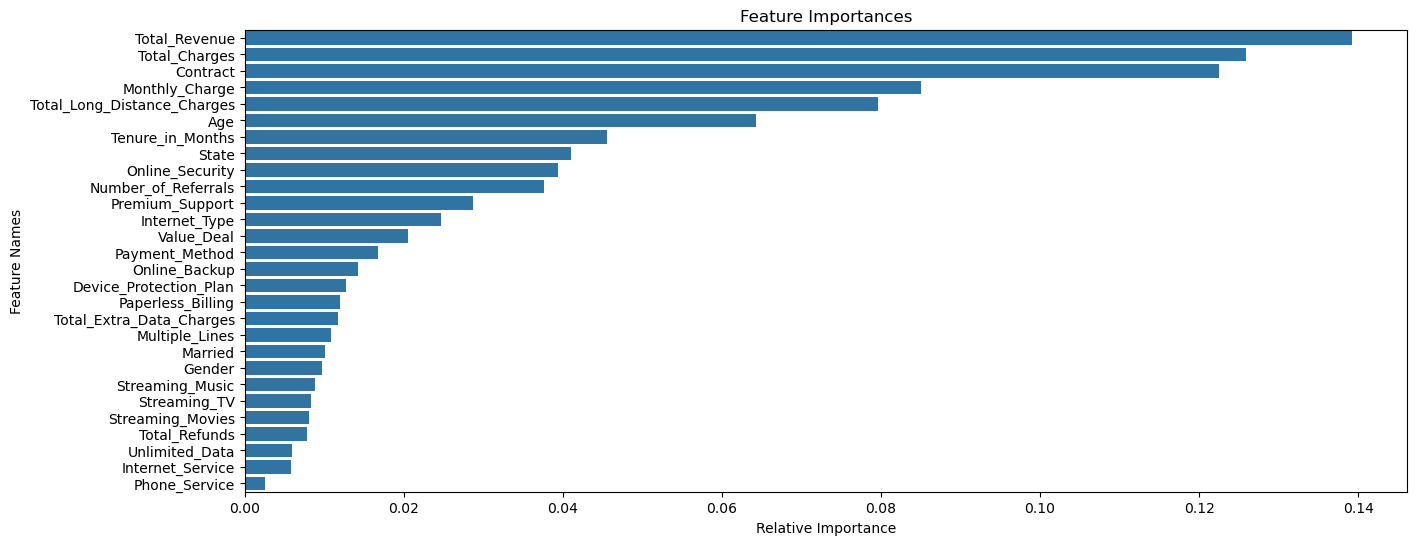

In [6]:
# Feature Importance
importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot Graph
plt.figure(figsize=(15,6))

sns.barplot(
    x=importances[indices],
    y=X.columns[indices]
)

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()

In [7]:
# Joiner File Path
join_file_path = r"D:\Data\Customer_Status_Predicted.xlsx"

# Read Joiner Data
new_data = pd.read_excel(
    join_file_path,
    sheet_name='vw_joindata'
)

# Keep Original Copy
original_data = new_data.copy()

# Clean Column Names
new_data.columns = new_data.columns.str.strip() \
                                   .str.replace(" ", "_") \
                                   .str.replace(r"[^\w]", "", regex=True)

# Show Data
print(new_data.head())

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal          72.10          72.1           0.0   
1      Cre

In [8]:
# Drop Extra Columns
new_data = new_data.drop(
    ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
    axis=1,
    errors='ignore'
)

# Fill Missing Values
new_data = new_data.fillna('Unknown')

# Encode Data
for column in new_data.columns:

    if column in label_encoders:

        new_data[column] = label_encoders[column].transform(
            new_data[column].astype(str)
        )

# Match Training Columns
new_data = new_data[X.columns]

print("Joiner Data Ready")

Joiner Data Ready


In [9]:
# Predict
new_predictions = rf_model.predict(new_data)

# Add Prediction Column
original_data['Customer_Status_Predicted'] = new_predictions

# Keep Only Churned Customers
original_data = original_data[
    original_data['Customer_Status_Predicted'] == 1
]

# Show Output
print(original_data.head())

# Total Predicted Customers
print(
    "Total Predicted Customers:",
    len(original_data)
)

# Save Final Output
original_data.to_csv(
    r"D:\Data\Predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

  Monthly_Charge Total_Charges Total_Refunds Total_Extra_Data_Charges  \
0          72.10          72.1           0.0                       